# **droppedaneuralnet**

Hello, my name is Noah. This is my investigation to solve the dropped neural network problem ([link](https://huggingface.co/spaces/jane-street/droppedaneuralnet)). We begin by defining the network components with the provided code from HF.



---



*TLDR: First testing and ruling out weaker pairing signals (bias/dead ReLU, and frobenius norm heuristics), we identified diagonal dominance as a relaible block layer matching criteria, then use an adjacency swap local search to recover the exact order getting 0 MSE.*

In [ ]:
# @title
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr

torch.manual_seed(0)
np.random.seed(0)

In [ ]:
class Block(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int):
        super().__init__()
        self.inp = nn.Linear(in_dim, hidden_dim)
        self.activation = nn.ReLU()
        self.out = nn.Linear(hidden_dim, in_dim)

    def forward(self, x):
        residual = x
        x = self.inp(x)
        x = self.activation(x)
        x = self.out(x)
        return residual + x

class LastLayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.layer = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        return self.layer(x)

In addition to the code, we are also given two other items.
1) the historical data (*historical_data.csv*), and
2) the layer weights (*pieces folder*).

Lets first take a look at the data.

In [ ]:
df = pd.read_csv('historical_data.csv')
print(df.columns)
df.head()

Index(['measurement_0', 'measurement_1', 'measurement_2', 'measurement_3',
       'measurement_4', 'measurement_5', 'measurement_6', 'measurement_7',
       'measurement_8', 'measurement_9', 'measurement_10', 'measurement_11',
       'measurement_12', 'measurement_13', 'measurement_14', 'measurement_15',
       'measurement_16', 'measurement_17', 'measurement_18', 'measurement_19',
       'measurement_20', 'measurement_21', 'measurement_22', 'measurement_23',
       'measurement_24', 'measurement_25', 'measurement_26', 'measurement_27',
       'measurement_28', 'measurement_29', 'measurement_30', 'measurement_31',
       'measurement_32', 'measurement_33', 'measurement_34', 'measurement_35',
       'measurement_36', 'measurement_37', 'measurement_38', 'measurement_39',
       'measurement_40', 'measurement_41', 'measurement_42', 'measurement_43',
       'measurement_44', 'measurement_45', 'measurement_46', 'measurement_47',
       'pred', 'true'],
      dtype='object')


,measurement_0,measurement_1,measurement_2,measurement_3,measurement_4,measurement_5,measurement_6,measurement_7,measurement_8,measurement_9,...,measurement_40,measurement_41,measurement_42,measurement_43,measurement_44,measurement_45,measurement_46,measurement_47,pred,true
0,-0.871934,-0.762225,-0.757929,-0.721084,1.028834,0.438896,-0.588406,0.506069,0.975882,-0.135539,...,-0.760506,-0.855748,-0.710793,-0.705868,-0.848239,-0.924884,-0.746422,-0.494147,-1.503336,-1.373331
1,-0.896439,-0.797072,-0.838245,-0.702223,-0.339256,0.275030,0.633057,0.806209,1.127910,1.008668,...,0.653162,0.981695,0.845496,0.613861,0.828901,0.993121,-0.189470,-0.694227,0.134370,0.769000
2,1.585834,1.394803,0.797784,0.915132,1.094983,-0.190658,-0.652446,1.292744,0.553290,-0.826261,...,0.937203,0.984563,0.732501,0.822113,0.971255,0.780424,1.054204,1.299329,-1.498503,-1.554865
3,-0.814730,1.862772,0.659989,-0.388819,1.017558,1.042258,-0.213992,1.737026,-0.816464,-0.966827,...,-0.710506,-0.833145,-0.797857,-0.767712,-0.577482,-0.640398,-0.766676,1.401744,-0.281622,-0.557710
4,-0.597139,0.370089,-0.906754,-0.331995,-0.764724,-0.681954,0.412134,1.583631,0.741060,0.717198,...,-0.664083,-0.552471,-0.843288,-0.819915,-0.804802,-0.912399,-0.259784,1.463677,-0.011268,-0.180500


It seems the data contains 48 non-specific features, as well as a ground truth column and a column that seems to be the predicted outputs of the neural network. Immedietly, a naive brute force solution presents itself; we could test every permutation of layers to check which set gives us the required output. However...

In [ ]:
pieces_folder = Path("pieces")
item_count = sum(1 for _ in pieces_folder.iterdir())
print(item_count)

97


We see there are 97 layers in our network, that would make 97! combinations, or roughly 10^151... so that definetly won't work. Therefore, we must come up with something else. Maybe first we should take a deeper look at our data and layer weights.

Rows: 10,000
Number of features: 48
pred/true correlation: 0.940488
MAE:  0.171507
RMSE: 0.326314


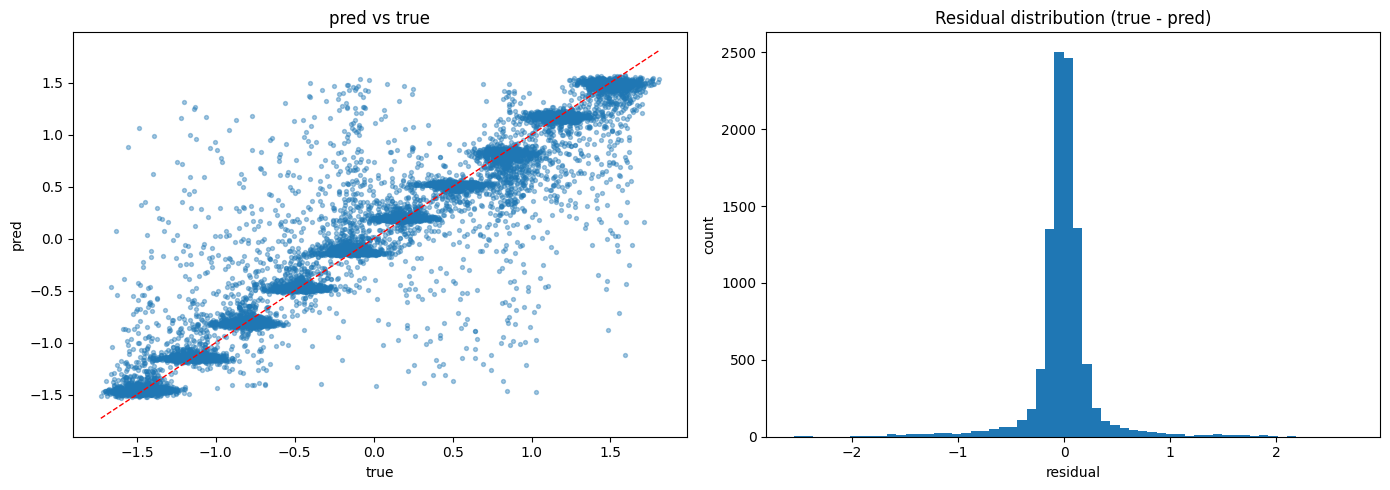

In [ ]:
feature_cols = [c for c in df.columns if c.startswith("measurement_")]

print(f"Rows: {len(df):,}")
print(f"Number of features: {len(feature_cols)}")
print(f"pred/true correlation: {df['pred'].corr(df['true']):.6f}")

residual = df["true"] - df["pred"]
print(f"MAE:  {residual.abs().mean():.6f}")
print(f"RMSE: {(residual.pow(2).mean() ** 0.5):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df["true"], df["pred"], s=8, alpha=0.4)
line_min = min(df["true"].min(), df["pred"].min())
line_max = max(df["true"].max(), df["pred"].max())
axes[0].plot([line_min, line_max], [line_min, line_max], "r--", linewidth=1)
axes[0].set_title("pred vs true")
axes[0].set_xlabel("true")
axes[0].set_ylabel("pred")

axes[1].hist(residual, bins=60)
axes[1].set_title("Residual distribution (true - pred)")
axes[1].set_xlabel("residual")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()



In [ ]:
def infer_dims(state_dict):
    if "weight" in state_dict:
        w = state_dict["weight"]
        return int(w.shape[1]), int(w.shape[0]), int(w.shape[0])  # in_dim, hidden_dim, out_dim
    if "inp.weight" in state_dict and "out.weight" in state_dict:
        return int(state_dict["inp.weight"].shape[1]), int(state_dict["inp.weight"].shape[0]), int(state_dict["out.weight"].shape[0])
    if "layer.weight" in state_dict:
        w = state_dict["layer.weight"]
        return int(w.shape[1]), int(w.shape[0]), int(w.shape[0])
    return np.nan, np.nan, np.nan

dim_rows = []
for path in sorted(pieces_folder.glob("piece_*.pth")):
    piece_idx = int(re.search(r"piece_(\d+)\.pth", path.name).group(1))
    state = torch.load(path, map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state and isinstance(state["state_dict"], dict):
        state = state["state_dict"]
    in_dim, hidden_dim, out_dim = infer_dims(state)
    dim_rows.append({
        "piece_idx": piece_idx,
        "in_dim": in_dim,
        "hidden_dim": hidden_dim,
        "out_dim": out_dim,
        "keys": ", ".join(state.keys()) if isinstance(state, dict) else str(type(state)),
    })
dims_df = pd.DataFrame(dim_rows).sort_values("piece_idx").reset_index(drop=True)
print("\nDimension pattern counts:")
print(dims_df.groupby(["in_dim", "hidden_dim", "out_dim"]).size().sort_values(ascending=False))
display(dims_df)

print("Idx of output:", dims_df.loc[dims_df["out_dim"].eq(1), "piece_idx"].tolist())


Dimension pattern counts:
in_dim  hidden_dim  out_dim
48      96          96         48
96      48          48         48
48      1           1           1
dtype: int64


,piece_idx,in_dim,hidden_dim,out_dim,keys
0,0,48,96,96,"weight, bias"
1,1,48,96,96,"weight, bias"
2,2,48,96,96,"weight, bias"
3,3,48,96,96,"weight, bias"
4,4,48,96,96,"weight, bias"
...,...,...,...,...,...
92,92,96,48,48,"weight, bias"
93,93,96,48,48,"weight, bias"
94,94,48,96,96,"weight, bias"
95,95,48,96,96,"weight, bias"


Idx of output: [85]


After that short investigation, we have learned three things.
1) the network is trained, we can see the predicted and true values correlate well, and perhaps more interestingly
2) There is a layer in the network with an output dimension of 1. This is most likely the output layer, we find its index is 85
3) We can see some of the layers have input dimension of 48 with output 96, while others have input 96 and output 48.

This matches with the provided residual block class, where each block has 2 linear layers each. Thus the problem decomposes into two phases. First, pair the linear layers together that form a block. Second, arranged these blocks in the correct order.

So that begs the question of how to match layers together that are in the same block. The hint is likely to come from the fact that these residual layers were trained together, lets take a deeper look.

At this point, my first hypothesis was related to dead ReLU's where input biases and output column norms might align across matching layers. As shown in the block below, this produced a nontrivial pairing signal, but on further downstream investigation using search to order the blocks, the MSE loss would plateau around 0.5, therefore it did not reconstruct the correct order. The following code block shows the signal, as well as evidence towards why it did not work:

Bias/norm alignment (discarded)
  Matched mean corr : 0.2073
  Random  mean corr : -0.0060
  Score ratio : 34.3756
  Permutation p-val : 0.0020
  Bias range        : [-0.473, 0.206]
  Dead fraction     : 0.0000


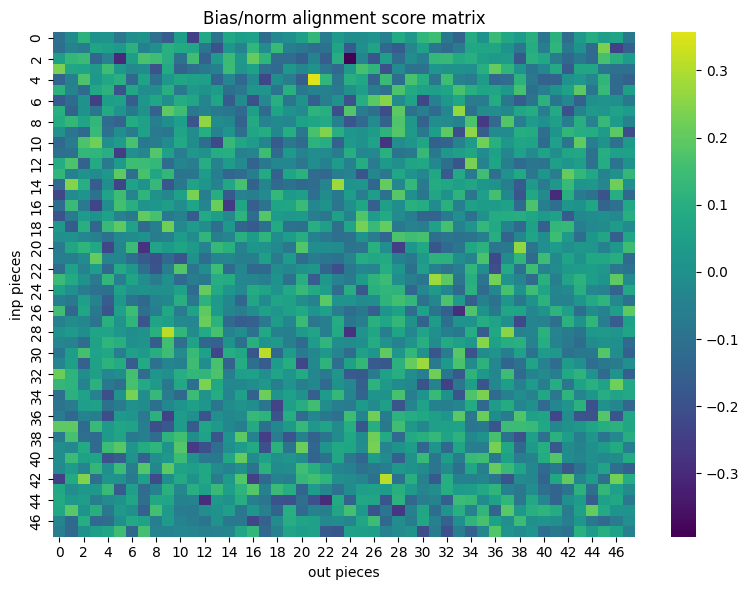

In [ ]:
from scipy.stats import pearsonr
from scipy.optimize import linear_sum_assignment

pieces, inp_list, out_list = {}, [], []
for path in sorted(pieces_folder.glob("piece_*.pth")):
    idx = int(re.search(r"piece_(\d+)\.pth", path.name).group(1))
    state = torch.load(path, map_location="cpu")
    # Handle nested state_dicts if present
    weights = state["state_dict"]["weight"] if "state_dict" in state else state["weight"]
    bias = state["state_dict"]["bias"] if "state_dict" in state else state["bias"]

    w = weights.numpy().astype(np.float64)
    b = bias.numpy().astype(np.float64)
    pieces[idx] = {"w": w, "b": b}

    if w.shape == (96, 48):
        inp_list.append(idx)
    elif w.shape == (48, 96):
        out_list.append(idx)

inp_list.sort()
out_list.sort()

n = len(inp_list)
corr_matrix = np.zeros((n, n), dtype=float)

for i, ii in enumerate(inp_list):
    inp_sig = np.asarray(pieces[ii]["b"], dtype=float)
    for j, oj in enumerate(out_list):
        out_sig = np.linalg.norm(np.asarray(pieces[oj]["w"], dtype=float), axis=0)
        corr_matrix[i, j] = pearsonr(inp_sig, out_sig)[0]

row_ind, col_ind = linear_sum_assignment(-corr_matrix)
matched_corrs = np.array([corr_matrix[i, j] for i, j in zip(row_ind, col_ind)])
random_corrs = np.array([corr_matrix[i, np.random.randint(n)] for i in range(n)])

all_biases = np.concatenate([np.asarray(pieces[i]["b"], dtype=float) for i in inp_list])

rng = np.random.default_rng(0)
perm_means = []
for _ in range(500):
    perm = rng.permutation(n)
    perm_means.append(corr_matrix[np.arange(n), perm].mean())
perm_means = np.asarray(perm_means)
p_val = (np.sum(perm_means >= matched_corrs.mean()) + 1) / (len(perm_means) + 1)

print("Bias/norm alignment (discarded)")
print(f"  Matched mean corr : {matched_corrs.mean():.4f}")
print(f"  Random  mean corr : {random_corrs.mean():.4f}")
print(f"  Score ratio : {abs(matched_corrs.mean() / random_corrs.mean()):.4f}")
print(f"  Permutation p-val : {p_val:.4f}")
print(f"  Bias range        : [{all_biases.min():.3f}, {all_biases.max():.3f}]")
print(f"  Dead fraction     : {(all_biases < -2.0).mean():.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap="viridis", center=0)
plt.title("Bias/norm alignment score matrix")
plt.xlabel("out pieces")
plt.ylabel("inp pieces")
plt.tight_layout()
plt.show()

Deceptively, the score ratio between the matched and random layers is very high at ~34. However, the heatmap is quite diffuse with no real patterns. This shows us that the signal is actually weak and spread across the matrix rather than concentrated in any clearly matched pairs. The large matched vs random ratio is thus not meaningful because the random baseline is near zero, so a small absolute difference will artificially inflate the ratio. Since the biases are not strongly negative and there are no actually dead units, there is no dead ReLU mechanism here to exploit. Lets try something else
<br>
<br>

---

<br>

Another natural object to investigate for pairing is the product of w_out @ w_in (a good contender since it is a easily computable quantity that contains information from both weight matrices). My next hypothesis is as follows:
<br>
<br>

*Layers that are paired together will produce a larger product.*

<br>

The motivation for this is because of co-adaptation, which is the phenomena in deep residual networks where layers trained together are updated together via gradient descent. In a stable training regime, these layers should be refined to constructively interfere in order to propagate signal.

Lets test this hypothesis by computing the frobenius norm to see if it seperates the matched and unmatched pairs...

In [ ]:
pieces, inp_list, out_list = {}, [], []
pieces_path = Path("pieces")
for path in sorted(pieces_path.glob("piece_*.pth")):
    idx   = int(re.search(r"piece_(\d+)\.pth", path.name).group(1))
    state = torch.load(path, map_location="cpu")
    w = state["weight"].numpy().astype(np.float64)
    b = state["bias"].numpy().astype(np.float64)
    pieces[idx] = {"w": w, "b": b}
    if   w.shape == (96, 48): inp_list.append(idx)
    elif w.shape == (48, 96): out_list.append(idx)
inp_list.sort(); out_list.sort()
n = len(inp_list)

meas_cols = [c for c in df.columns if c.startswith("measurement_")]
X = torch.tensor(df[meas_cols].values, dtype=torch.float32)
pred_target = torch.tensor(df["pred"].values, dtype=torch.float32)

frob_matrix = np.zeros((n, n))
for i, ii in enumerate(inp_list):
    W_inp = pieces[ii]["w"]
    for j, oj in enumerate(out_list):
        frob_matrix[i, j] = np.linalg.norm(pieces[oj]["w"] @ W_inp, "fro")

row_ind_f, col_ind_f = linear_sum_assignment(-frob_matrix)
matched_frob = [frob_matrix[i, j] for i, j in zip(row_ind_f, col_ind_f)]
random_frob  = [frob_matrix[i, np.random.randint(n)] for i in range(n)]

print(f"Frobenius norm signal")
print(f"  Matched mean  : {np.mean(matched_frob):.4f}")
print(f"  Random mean   : {np.mean(random_frob):.4f}")
print(f"  Score ratio   : {np.mean(matched_frob) / np.mean(random_frob):.3f}")

Frobenius norm signal
  Matched mean  : 3.2044
  Random mean   : 2.9662
  Score ratio   : 1.080


A score ratio of 1.080, so barely above random. There is a very small real signal, but very few will be high confidence under this method.

The Frobenius norm measures magnitude, which is counfounded by the scale of the individual weights. A large w_in and out will make a large product regardless of whether they were actually trained together. Thus we need to find something that is a structural property that training imprints on matching pairs that random combinations won't have.

Let us take a step back for a moment and try to reason from first principles instead of diving right in. These blocks in the network were trained together via gradient descent, so for the network to be stable across 48 layers, each block's contribution to the residual stream cant be too expansive. The jacobian of the block is 

I + (1/2)(w_out @ w_in)

So w_out @ w_in needs small, slightly negative eigenvalues. This could be a good property that random pairings won't have, lets check.

In [1]:
rng = np.random.default_rng(0)
print(f"{'pair':<25} {'mean_eig':>10} {'trace':>10}")
print("-" * 47)
for label, ii, oj in [
    ("matched",  inp_list[0], out_list[0]),
    ("matched",  inp_list[1], out_list[1]),
    ("matched",  inp_list[2], out_list[2]),
    ("mismatch", inp_list[0], out_list[rng.integers(1,n)]),
    ("mismatch", inp_list[1], out_list[rng.integers(1,n)]),
    ("mismatch", inp_list[2], out_list[rng.integers(1,n)]),
]:
    prod = pieces[oj]["w"] @ pieces[ii]["w"]
    eigs = np.linalg.eigvals(prod).real
    print(f"inp={ii:>2} out={oj:>2} [{label}]  {eigs.mean():>10.4f}  {np.trace(prod):>10.4f}")

NameError: name 'np' is not defined

The matched pairs seem to cluster negative, whereas the mismatches are near zero. Since trace is just the sum of eigenvalues we can use that as our signal. Finally we can normalize by the frobenius norm to avoid the scale issue we noticed earlier. Lets see what this looks like visually:

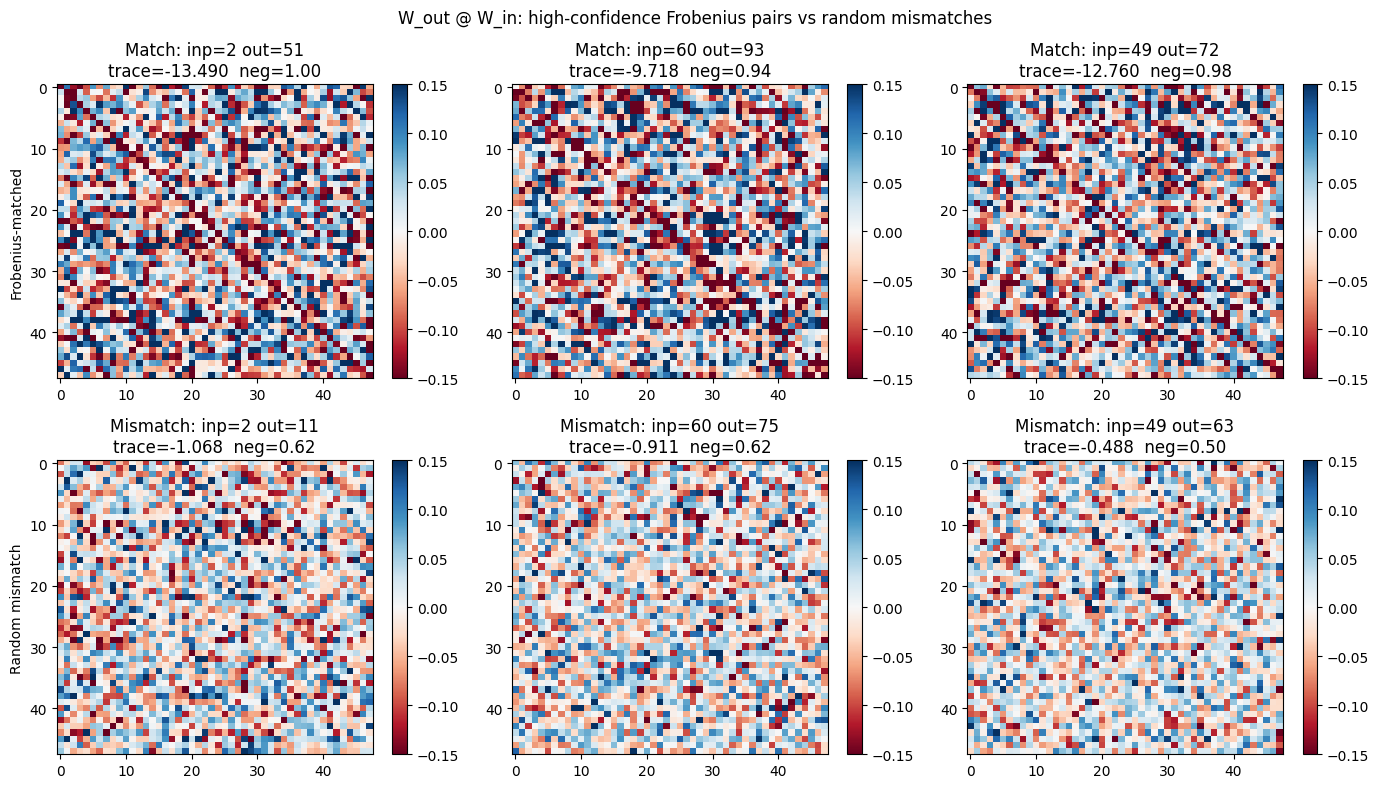

  Pair                         trace   neg_frac   |trace|/frob
  ------------------------------------------------------------
  inp= 2 out=51 [MATCHED]   -13.490        1.00          2.4070
  inp=60 out=93 [MATCHED]    -9.718        0.94          1.7639
  inp=49 out=72 [MATCHED]   -12.760        0.98          2.4469
  inp= 2 out=11 [MISMATCH]    -1.068        0.62          0.2935
  inp=60 out=75 [MISMATCH]    -0.911        0.62          0.2716
  inp=49 out=63 [MISMATCH]    -0.488        0.50          0.1516


In [ ]:
conf_ratio = []
for i in range(n):
    row = frob_matrix[i]; s = np.sort(row)[::-1]
    conf_ratio.append((s[0]/s[1], i, np.argmax(row)))
conf_ratio.sort(reverse=True)

top3 = [(inp_list[i], out_list[j]) for _, i, j in conf_ratio[:3]]
rng = np.random.default_rng(42)
rand3 = [(inp_list[conf_ratio[k][1]], out_list[rng.choice([j for j in range(n) if j != conf_ratio[k][2]])]) for k in range(3)]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("W_out @ W_in: high-confidence Frobenius pairs vs random mismatches", fontsize=12)

for col, (ii, oj) in enumerate(top3):
    prod = pieces[oj]["w"] @ pieces[ii]["w"]
    ax = axes[0, col]
    im = ax.imshow(prod, cmap="RdBu", vmin=-0.15, vmax=0.15, aspect="auto")
    diag = np.diag(prod)
    ax.set_title(f"Match: inp={ii} out={oj}\ntrace={diag.sum():.3f}  neg={( diag<0).mean():.2f}")
    plt.colorbar(im, ax=ax)

for col, (ii, oj) in enumerate(rand3):
    prod = pieces[oj]["w"] @ pieces[ii]["w"]
    ax = axes[1, col]
    im = ax.imshow(prod, cmap="RdBu", vmin=-0.15, vmax=0.15, aspect="auto")
    diag = np.diag(prod)
    ax.set_title(f"Mismatch: inp={ii} out={oj}\ntrace={diag.sum():.3f}  neg={( diag<0).mean():.2f}")
    plt.colorbar(im, ax=ax)

axes[0,0].set_ylabel("Frobenius-matched", fontsize=10)
axes[1,0].set_ylabel("Random mismatch", fontsize=10)
plt.tight_layout(); plt.show()

# Print diagonal statistics
print(f"  {'Pair':<25} {'trace':>8} {'neg_frac':>10} {'|trace|/frob':>14}")
print(f"  {'-'*60}")
for label, group in [("MATCHED", top3), ("MISMATCH", rand3)]:
    for ii, oj in group:
        prod = pieces[oj]["w"] @ pieces[ii]["w"]
        diag = np.diag(prod)
        frob = np.linalg.norm(prod, "fro")
        print(f"  inp={ii:>2} out={oj:>2} [{label}]  "
              f"{diag.sum():>8.3f}  {(diag<0).mean():>10.2f}  {abs(diag.sum())/frob:>14.4f}")

Wow! it seems there is a good pattern here. Matched pairs seem to have 90% of their diagonal entries negative and traces in the -10 to -14 range. On the other hand, random pairs are only 50-60% negative and have near zero traces, which is consistent with random chance!

Upon further thought, this makes sense. The training algorithm, in order to keep the network stable, should produce patterns like this. The jacobian of each block is:

dy/dx = I + w_out * d * w_in

where d is the diagonal ReLU mask. With a ~50% neuron activation, d will roughly be (1/2) * I, therefore:

dy/dx = I + (1/2)*(w_out @ w_in)

Then for 48 stacked blocks to train without the residual stream blowing up, each jacobian needs eigenvalues close to 1, i.e. the eigenvalues of w_out @ w_in need to be small and slightly negative. In other words a mildly contractive block is stable, a mildly expansive one compounds catastrophically across all 48 layers. This is further enforced by weight decay with gradient descent, giving us a negative diagonal on every correctly matched product matrix.

Thus, our pairing metric becomes:

score(inp_i, out_j) = |trace(W_out_j @ W_in_i)|  /  ||W_out_j @ W_in_i||_F

Where the numerator captures the negative diagonal component, dividing by the norm makes it scale invariant as well. Matched pairs score highly in our sample above and mismatches should score low.

Lets apply our pairing:

In [ ]:
diag_matrix = np.zeros((n, n))
for i, ii in enumerate(inp_list):
    W_inp = pieces[ii]["w"]
    for j, oj in enumerate(out_list):
        prod = pieces[oj]["w"] @ W_inp
        diag_matrix[i,j] = abs(np.trace(prod)) / np.linalg.norm(prod, "fro")

row_ind, col_ind = linear_sum_assignment(-diag_matrix)

matched_scores = [diag_matrix[i, j] for i, j in zip(row_ind, col_ind)]
unmatched_scores = [diag_matrix[i, j]
                    for i in range(n) for j in range(n)
                    if j != col_ind[i]]

print(f"Diagonal dominance - score distribution:")
print(f"  Matched pairs   min={min(matched_scores):.4f}  max={max(matched_scores):.4f}")
print(f"  Unmatched pairs min={min(unmatched_scores):.4f}  max={max(unmatched_scores):.4f}")
print(f"  Gap between worst match and best non-match: "
      f"{min(matched_scores) - max(unmatched_scores):.4f}")

Diagonal dominance - score distribution:
  Matched pairs   min=1.7639  max=3.2320
  Unmatched pairs min=0.0001  max=0.5838
  Gap between worst match and best non-match: 1.1801


Now that we have our pairing, we will verify it using two different diagnostics. First is a scalar score, the diagonal dominance ratio, which should be much larger for correctly matched pairs than for mismatches:

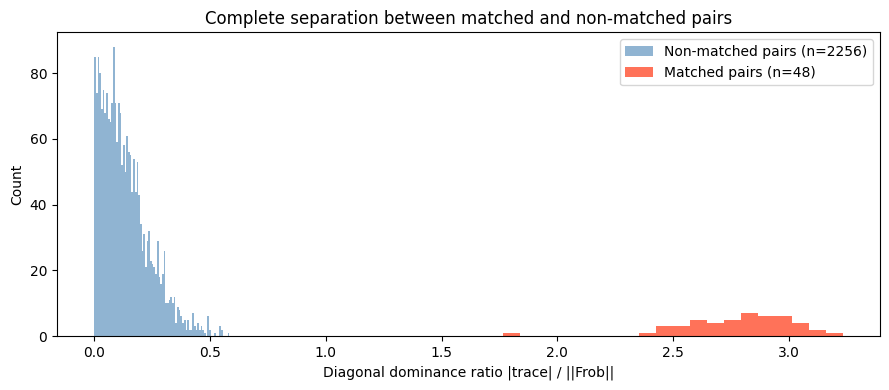


48 pairs recovered. Proceeding to ordering.


In [ ]:
# Visualise the separation
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(unmatched_scores, bins=80, alpha=0.6, label=f"Non-matched pairs (n={len(unmatched_scores)})",
        color="steelblue")
ax.hist(matched_scores, bins=20, alpha=0.9, label=f"Matched pairs (n={len(matched_scores)})",
        color="tomato")
ax.set_xlabel("Diagonal dominance ratio |trace| / ||Frob||")
ax.set_ylabel("Count")
ax.set_title("Complete separation between matched and non-matched pairs")
ax.legend()
plt.tight_layout(); plt.show()

blocks = [{"inp_piece": inp_list[i], "out_piece": out_list[j]}
          for i, j in zip(row_ind, col_ind)]
print(f"\n48 pairs recovered. Proceeding to ordering.")

The matched and unmatched distributions are well seperated, which strongly demonstrates that the pairing is correct.

Now next we visualize the full products of w_out @ w_in for all our estimated paired blocks. If the pairing is correct, these matrices should show a consistent structure instead of random noise.

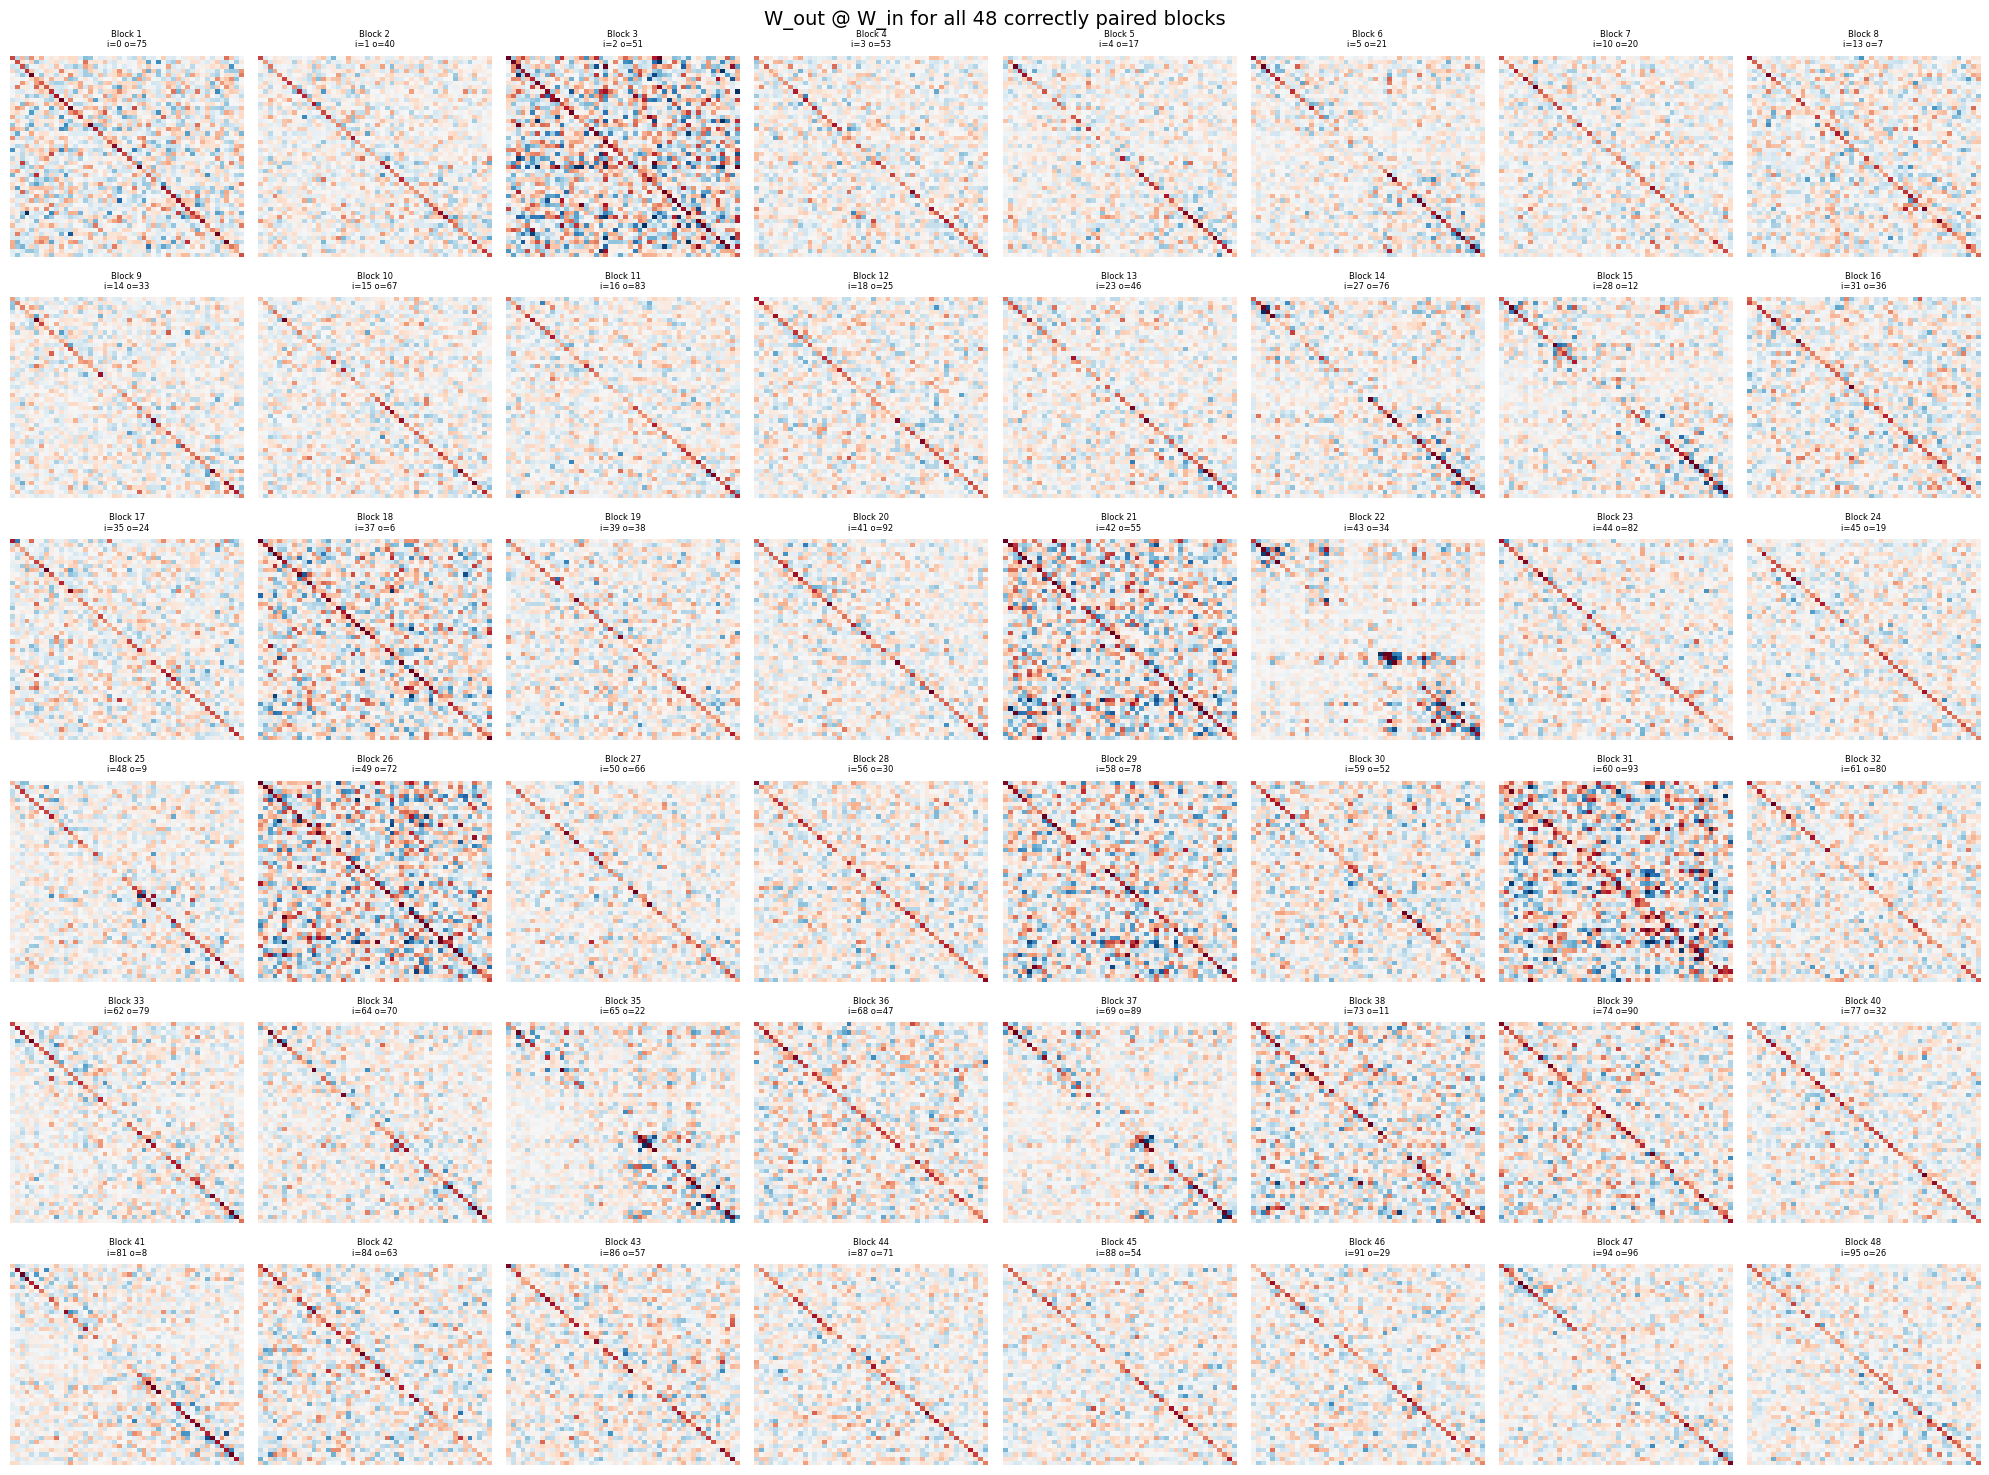

In [ ]:
fig, axes = plt.subplots(6, 8, figsize=(20, 15))
fig.suptitle("W_out @ W_in for all 48 correctly paired blocks",
             fontsize=14)
# Use the 'blocks' list directly as it is defined before this cell
for rank, (ax, b) in enumerate(zip(axes.flat, blocks)):
    prod = pieces[b["out_piece"]]["w"] @ pieces[b["inp_piece"]]["w"]
    ax.imshow(prod, cmap="RdBu", vmin=-0.3, vmax=0.3, aspect="auto")
    ax.set_title(f"Block {rank+1}\ni={b['inp_piece']} o={b['out_piece']}", fontsize=6)
    ax.axis("off")
plt.tight_layout(); plt.show()

The recurring diagonal band across all the plots here is some strong qualitative evidence. The structure is not fully identical across all the blocks, but coherent enough that coupled with the other plot provides a strong signal our matching is right.

Lets go ahead and try ordering our newly paired blocks. Blocks earlier in a neural network tend to make smaller adjustments to the residual stream whereas later ones make large adjustments as features are progressively combined towards the output. We can measure this by computing the l2 norm of the perturbation w_out * ReLU(w_in * x + b) for each block across the data. Sorting blocks by the ascending value here (the delta norm) given an initial order, of which we can refine by using an adjacency swap method on the MSE against the known predictions. Lets give it a shot:

In [ ]:
for idx in pieces:
    pieces[idx]["Wt"] = torch.tensor(pieces[idx]["w"], dtype=torch.float32)
    pieces[idx]["bt"] = torch.tensor(pieces[idx]["b"], dtype=torch.float32)

ls = torch.load(pieces_folder / "piece_85.pth", map_location="cpu")
W_last = ls["weight"].clone().detach().float()
b_last = ls["bias"].clone().detach().float()
F = torch.nn.functional
X_test = X[:2000];  y_test = pred_target[:2000]

def run_network(order, X_in):
    x = X_in.clone()
    with torch.no_grad():
        for b in order:
            inp, out = b["inp_piece"], b["out_piece"]
            x = x + F.linear(
                torch.relu(F.linear(x, pieces[inp]["Wt"], pieces[inp]["bt"])),
                pieces[out]["Wt"], pieces[out]["bt"])
        return F.linear(x, W_last, b_last).squeeze()

def mse(order):
    return torch.mean((run_network(order, X_test) - y_test) ** 2).item()

# Delta-norm seed
X_sub = X[:500]
for b in blocks:
    with torch.no_grad():
        inp, out = b["inp_piece"], b["out_piece"]
        p = F.linear(
            torch.relu(F.linear(X_sub, pieces[inp]["Wt"], pieces[inp]["bt"])),
            pieces[out]["Wt"], pieces[out]["bt"])
        b["delta_norm"] = torch.linalg.vector_norm(p, dim=1).mean().item()

ordered  = sorted(blocks, key=lambda b: b["delta_norm"])
seed_mse = mse(ordered)
print(f"Delta-norm seed MSE: {seed_mse:.6f}")

# Adjacent-swap hill-climbing
best, current, improved, round_n = seed_mse, list(ordered), True, 0
while improved:
    improved = False;  swaps = 0;  round_n += 1
    for i in range(len(current) - 1):
        c = list(current);  c[i], c[i+1] = c[i+1], c[i]
        m = mse(c)
        if m < best - 1e-10:
            best, current, improved = m, c, True;  swaps += 1
    print(f"  Round {round_n:>2}: {swaps:>3} swap(s)   MSE = {best:.8f}")
    if best < 1e-6:
        print(f"\n Solved in round {round_n}"); break

print(f"\nFinal MSE: {best:.10f}")

sequence = []
for b in current:
    sequence.extend([b["inp_piece"], b["out_piece"]])
sequence.append(85)
assert len(sequence) == 97 and sorted(sequence) == list(range(97))
print("\nSubmission:\n" + ",".join(map(str, sequence)))

Delta-norm seed MSE: 0.028580
  Round  1:  25 swap(s)   MSE = 0.01619094
  Round  2:  16 swap(s)   MSE = 0.01001757
  Round  3:  18 swap(s)   MSE = 0.00670256
  Round  4:  13 swap(s)   MSE = 0.00439407
  Round  5:  10 swap(s)   MSE = 0.00229325
  Round  6:  12 swap(s)   MSE = 0.00127917
  Round  7:  11 swap(s)   MSE = 0.00053373
  Round  8:   3 swap(s)   MSE = 0.00022734
  Round  9:   1 swap(s)   MSE = 0.00019384
  Round 10:   1 swap(s)   MSE = 0.00011146
  Round 11:   1 swap(s)   MSE = 0.00004325
  Round 12:   1 swap(s)   MSE = 0.00000000

 Solved in round 12

Final MSE: 0.0000000000

Submission:
43,34,65,22,69,89,28,12,27,76,81,8,5,21,62,79,64,70,94,96,4,17,48,9,23,46,14,33,95,26,50,66,1,40,15,67,41,92,16,83,77,32,10,20,3,53,45,19,87,71,88,54,39,38,18,25,56,30,91,29,44,82,35,24,61,80,86,57,31,36,13,7,59,52,68,47,84,63,74,90,0,75,73,11,37,6,58,78,42,55,49,72,2,51,60,93,85


Great, we got down to 0 MSE by the end, meaning our arrangement perfectly produces the predicted column of the provided dataset. Our final layer order is thus:

**43,34,65,22,69,89,28,12,27,76,81,8,5,21,62,79,64,70,94,96,4,17,48,9,23,46,14,33,95,26,50,66,1,40,15,67,41,92,16,83,77,32,10,20,3,53,45,19,87,71,88,54,39,38,18,25,56,30,91,29,44,82,35,24,61,80,86,57,31,36,13,7,59,52,68,47,84,63,74,90,0,75,73,11,37,6,58,78,42,55,49,72,2,51,60,93,85**

Finally, even though our MSE of 0 tells us that our order is correct, lets do a little more investigation into our method. The figure below checks whether the delta norm heuristic aligns with depth like we hypothesized. If it does, then like we suggested blocks later in the network have a larger delta norm value.

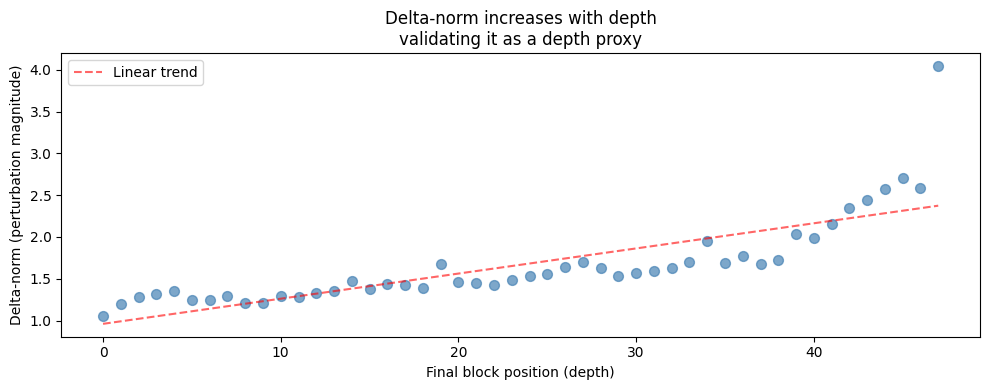

Pearson correlation between delta-norm and final depth: 0.8019


In [ ]:
final_positions = {b["inp_piece"]: rank for rank, b in enumerate(current)}

depth_data = [(final_positions[b["inp_piece"]], b["delta_norm"]) for b in blocks]
depth_data.sort()
positions, dnorms = zip(*depth_data)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(positions, dnorms, alpha=0.7, color="steelblue", s=50)
ax.set_xlabel("Final block position (depth)")
ax.set_ylabel("Delta-norm (perturbation magnitude)")
ax.set_title("Delta-norm increases with depth\n"
             "validating it as a depth proxy")
# Add trend line
z = np.polyfit(positions, dnorms, 1)
p = np.poly1d(z)
ax.plot(sorted(positions), p(sorted(positions)), "r--", alpha=0.6, label="Linear trend")
ax.legend(); plt.tight_layout(); plt.show()

r, _ = pearsonr(list(positions), list(dnorms))
print(f"Pearson correlation between delta-norm and final depth: {r:.4f}")

We can see above that on the whole delta norm trends up, although not monotonically. Thus, while a good heuristic and lead us to our answer, it is not perfect.